In [1]:
import numpy as np
import matplotlib.pyplot as plt
import proplot as plot
import pandas as pd
import os
import xarray as xr


In [2]:

def pred_TEX_from_t_sf2_tc(tex):
       return 0.012*tex + 0.33

In [3]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'

In [4]:
fpath = fr'/home/ronnie/Documents/GitHub/culRI-Bayesian/nc_files'
fname = 'ds06_calculated_ocean_properties.nc'

ds = xr.open_dataset(f'{fpath}/{fname}')
ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [5]:
fpath2 = fr'{local_documents_path}/Postdoc/TEXAS-PSM/netcdf/WOA-database/WOA23/WOA-decav'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [6]:
### NEMO nitrate data
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/no3'
fname = r'mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc'

nitrate_CMEMS_ds = xr.open_dataset(os.path.join(fpath,fname))
nitrate_CMEMS_ds = nitrate_CMEMS_ds.isel(time=0).drop('time')
nitrate_CMEMS_ds = nitrate_CMEMS_ds.rename({'latitude':'lat','longitude':'lon'})
nitrate_CMEMS_da = nitrate_CMEMS_ds.no3.load() ### convert mmol/L to umol/L to make it comparable to WOA data
nitrate_CMEMS_da

depth_coord = nitrate_CMEMS_da.depth
depth_coord = depth_coord - depth_coord[0]
nitrate_CMEMS_da = nitrate_CMEMS_da.assign_coords(depth=depth_coord)
nitrate_CMEMS_da

<xarray.DataArray 'no3' (depth: 75, lat: 681, lon: 1440)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [5.7781367, 5.779535 , 5.7808266, ..., 5.7733583, 5.775043 ,
         5.7766376],
        [5.720044 , 5.7206492, 5.721291 , ..., 5.718462 , 5.7189493,
         5.719477 ],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75 90.0
  * depth    (depth) float32 0.0 1.05 2.162 ... 5.494e+03 5.698e+03 5.902e+03
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

In [7]:
CMEMS_no3_100m_avg = nitrate_CMEMS_da.sel(depth=slice(0,100)).mean(dim='depth')
CMEMS_no3_100m_avg

<xarray.DataArray 'no3' (lat: 681, lon: 1440)>
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [6.2664714, 6.267922 , 6.269262 , ..., 6.2615128, 6.263262 ,
        6.264915 ],
       [6.192842 , 6.1934133, 6.1940236, ..., 6.191383 , 6.1918244,
        6.1923127],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75 90.0

In [8]:
fpath = fr'/home/ronnie/Documents/GitHub/culRI-Bayesian/spreadsheets'
fname = 'reg_data_revised_122024.csv'

coretop_df = pd.read_csv(f'{fpath}/{fname}', delimiter=',', header=0)
coretop_df

,sampleID,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,fGDGT_0,...,residual_TEX86_kim10H,depth_bin,TEX_residual_OLS,TEX_residual_log10TEX,TEX_residual_OLS_exclude_RS,TEX_residual_log10TEX_exclude_RS,TEX_residual_OLS_thermoT_integral,TEX_residual_log10TEX_thermoT_integral,TEX_residual_OLS_exclude_RS_thermoT_integral,TEX_residual_log10TEX_exclude_RS_thermoT_integral
0,TEXAS_PSM_RR00002,KNR195-5 MC11,MC,6.0,8.0,-1.5327,-86.7852,2288.0,0.602873,0.330589,...,-0.000488,"(2000, 3000]",-0.003968,0.004421,0.000231,0.007747,0.012897,0.023712,0.016545,0.026355
1,TEXAS_PSM_RR00005,KNR195-5 MC18,MC,4.0,6.0,-3.9690,-81.3100,1024.0,0.599447,0.282415,...,0.029586,"(1000, 2000]",0.013049,0.024335,0.016731,0.027141,0.007403,0.017950,0.011109,0.020646
2,TEXAS_PSM_RR00007,KNR195-5 MC25,MC,5.0,7.0,-3.5830,-81.1650,381.0,0.617192,0.292011,...,0.027219,"(0, 1000]",0.018381,0.028019,0.022377,0.031137,0.027611,0.038477,0.031248,0.041110
3,TEXAS_PSM_RR00008,KNR195-5 MC33,MC,3.0,5.0,-3.2237,-82.9142,2949.0,0.605147,0.309270,...,0.038849,"(2000, 3000]",0.020994,0.032542,0.024620,0.035293,0.032989,0.045734,0.036133,0.047936
4,TEXAS_PSM_RR00009,KNR195-5 MC34,MC,4.0,6.0,-3.5975,-83.9632,3224.0,0.588670,0.344233,...,0.009721,"(3000, 4000]",-0.003390,0.007186,0.000436,0.010133,0.012130,0.024464,0.015398,0.026772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,TEXAS_PSM_RR02077,SY201710_LD-18,NaN,NaN,NaN,20.5700,113.8000,89.0,0.595556,0.236000,...,-0.054672,"(0, 1000]",-0.038058,-0.034899,-0.033182,-0.030835,-0.054613,-0.055616,-0.049261,-0.051265
1761,TEXAS_PSM_RR02078,DO201207-08_QD11a,NaN,NaN,NaN,20.7000,113.3700,81.0,0.512500,0.281000,...,-0.135656,"(0, 1000]",-0.119972,-0.116555,-0.115124,-0.112524,-0.140778,-0.142625,-0.135338,-0.138176
1762,TEXAS_PSM_RR02079,DO201207-08_QD41,NaN,NaN,NaN,20.1400,112.0600,87.0,0.585859,0.236000,...,-0.068119,"(0, 1000]",-0.049813,-0.047126,-0.044885,-0.043002,-0.071414,-0.074382,-0.065861,-0.069805
1763,TEXAS_PSM_RR02080,DO201207-08_E503,NaN,NaN,NaN,19.2000,112.2900,189.0,0.651376,0.237000,...,-0.017503,"(0, 1000]",0.007641,0.008382,0.012773,0.012742,0.009346,0.010442,0.014468,0.014541


In [9]:
coretop_df['t_sf2tc_avg'] = [ds['t_sf2tc_avg'].sel(lat=lat, lon=lon, method='nearest').values for lat, lon in zip(coretop_df['Latitude'], coretop_df['Longitude'])]
coretop_df['pred_tex'] = pred_TEX_from_t_sf2_tc(coretop_df['t_sf2tc_avg'])
coretop_df['tex_residual'] = coretop_df['TEX86'] - coretop_df['pred_tex']
coretop_df['no3_sf2tc_avg'] = [ds['no3_sf2tc_avg'].sel(lat=lat, lon=lon, method='nearest').values for lat, lon in zip(coretop_df['Latitude'], coretop_df['Longitude'])]
coretop_df['no3_100m_avg'] = [CMEMS_no3_100m_avg.sel(lat=lat, lon=lon, method='nearest').values for lat, lon in zip(coretop_df['Latitude'], coretop_df['Longitude'])]

In [10]:
fname = 'SonneCoretopTexUk.xlsx'
fpath = fr'/home/ronnie/Documents/GitHub/culRI-Bayesian/spreadsheets'
trang_coretop_df = pd.read_excel(os.path.join(fpath,fname), sheet_name='Tex86_0-2cm',skiprows=2)
features = ['Sample label', 'WaterDepth', 'Latitude', 'Longitude', 'Sample depth',
       'ASE#', 'TEX86','BIT','MI',"RI-sample","Annual SST"]
## drop the first row
trang_coretop_df = trang_coretop_df[features].drop(0)
trang_coretop_df = trang_coretop_df.iloc[:37,:].reset_index(drop=True)

trang_coretop_df['t_sf2tc_avg'] =  [ds['t_sf2tc_avg'].sel(lat=trang_coretop_df['Latitude'][i], 
                                                            lon=trang_coretop_df['Longitude'][i], 
                                                            method='nearest').values for i in range(len(trang_coretop_df))]
trang_coretop_df['pred_tex'] = pred_TEX_from_t_sf2_tc(trang_coretop_df['t_sf2tc_avg'])
trang_coretop_df['tex_residual'] =  trang_coretop_df['TEX86'] - trang_coretop_df['pred_tex']
trang_coretop_df['no3_sf2tc_avg'] = [ds['no3_sf2tc_avg'].sel(lat=trang_coretop_df['Latitude'][i],
                                                                lon=trang_coretop_df['Longitude'][i], 
                                                                method='nearest').values for i in range(len(trang_coretop_df))]
trang_coretop_df['no3_100m_avg'] = [CMEMS_no3_100m_avg.sel(lat=trang_coretop_df['Latitude'][i],
                                                            lon=trang_coretop_df['Longitude'][i], 
                                                            method='nearest').values for i in range(len(trang_coretop_df))]

       
trang_coretop_df

,Sample label,WaterDepth,Latitude,Longitude,Sample depth,ASE#,TEX86,BIT,MI,RI-sample,Annual SST,t_sf2tc_avg,pred_tex,tex_residual,no3_sf2tc_avg,no3_100m_avg
0,18547,1460.5,-15.05515,120.4362,0-1cm,b1_2,0.720611,0.062592,0.208564,2.836628,28.225882,25.272139,0.633266,0.087345,2.7273462,0.08229633
1,18549,1628.5,-15.96155,119.50967,0-1cm,b2_3,0.703018,0.060624,0.208589,2.72996,28.04435,27.065815,0.65479,0.048229,0.05136171,0.07693834
2,18550,1388,-16.85953,118.75702,0-1cm,b1_9,0.738653,0.067271,0.197568,2.882912,27.720236,24.87637,0.628516,0.110136,2.5489287,0.07636642
3,18551,668.8,-17.59155,118.44568,0-1cm,b1_4,0.742189,0.083749,0.189787,3.027884,27.527098,24.018946,0.618227,0.123962,3.9045472,0.062232908
4,18552,1951.3,-17.67595,117.69402,0-1cm,b1_6,0.726546,0.038405,0.195816,2.889367,27.402267,23.968073,0.617617,0.108929,3.6551843,0.0664947
5,18553,1619.7,-18.11635,117.11663,0-1cm,b2_13,0.756038,0.07958,0.167178,3.10767,27.187714,23.977802,0.617734,0.138305,3.3688889,0.06557346
6,18554,497.9,-18.53323,117.36642,0-1cm,b1_8,0.722431,0.049343,0.192907,3.009234,27.09817,24.092031,0.619104,0.103326,3.397833,0.045964282
7,18555,1113.7,-18.35085,117.25673,0-1cm,b1_1,0.714983,0.027977,0.194372,2.946217,27.17896,24.054403,0.618653,0.09633,3.4231243,0.052999575
8,18556,1843.6,-17.1036,117.23048,1-2cm,b1_7,0.767526,0.071262,0.154943,3.064514,27.420599,24.647125,0.625766,0.14176,2.3372893,0.0851014
9,18557,2405.9,-17.54862,117.14593,0-1cm,b2_5,0.822995,0.14289,0.12297,3.356551,27.302599,23.9062,0.616874,0.206121,3.5125499,0.07463976


In [11]:
ds['tc_depth'].max()

<xarray.DataArray 'tc_depth' ()>
array(1050., dtype=float32)

/home/ronnie/miniforge3/envs/stan/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


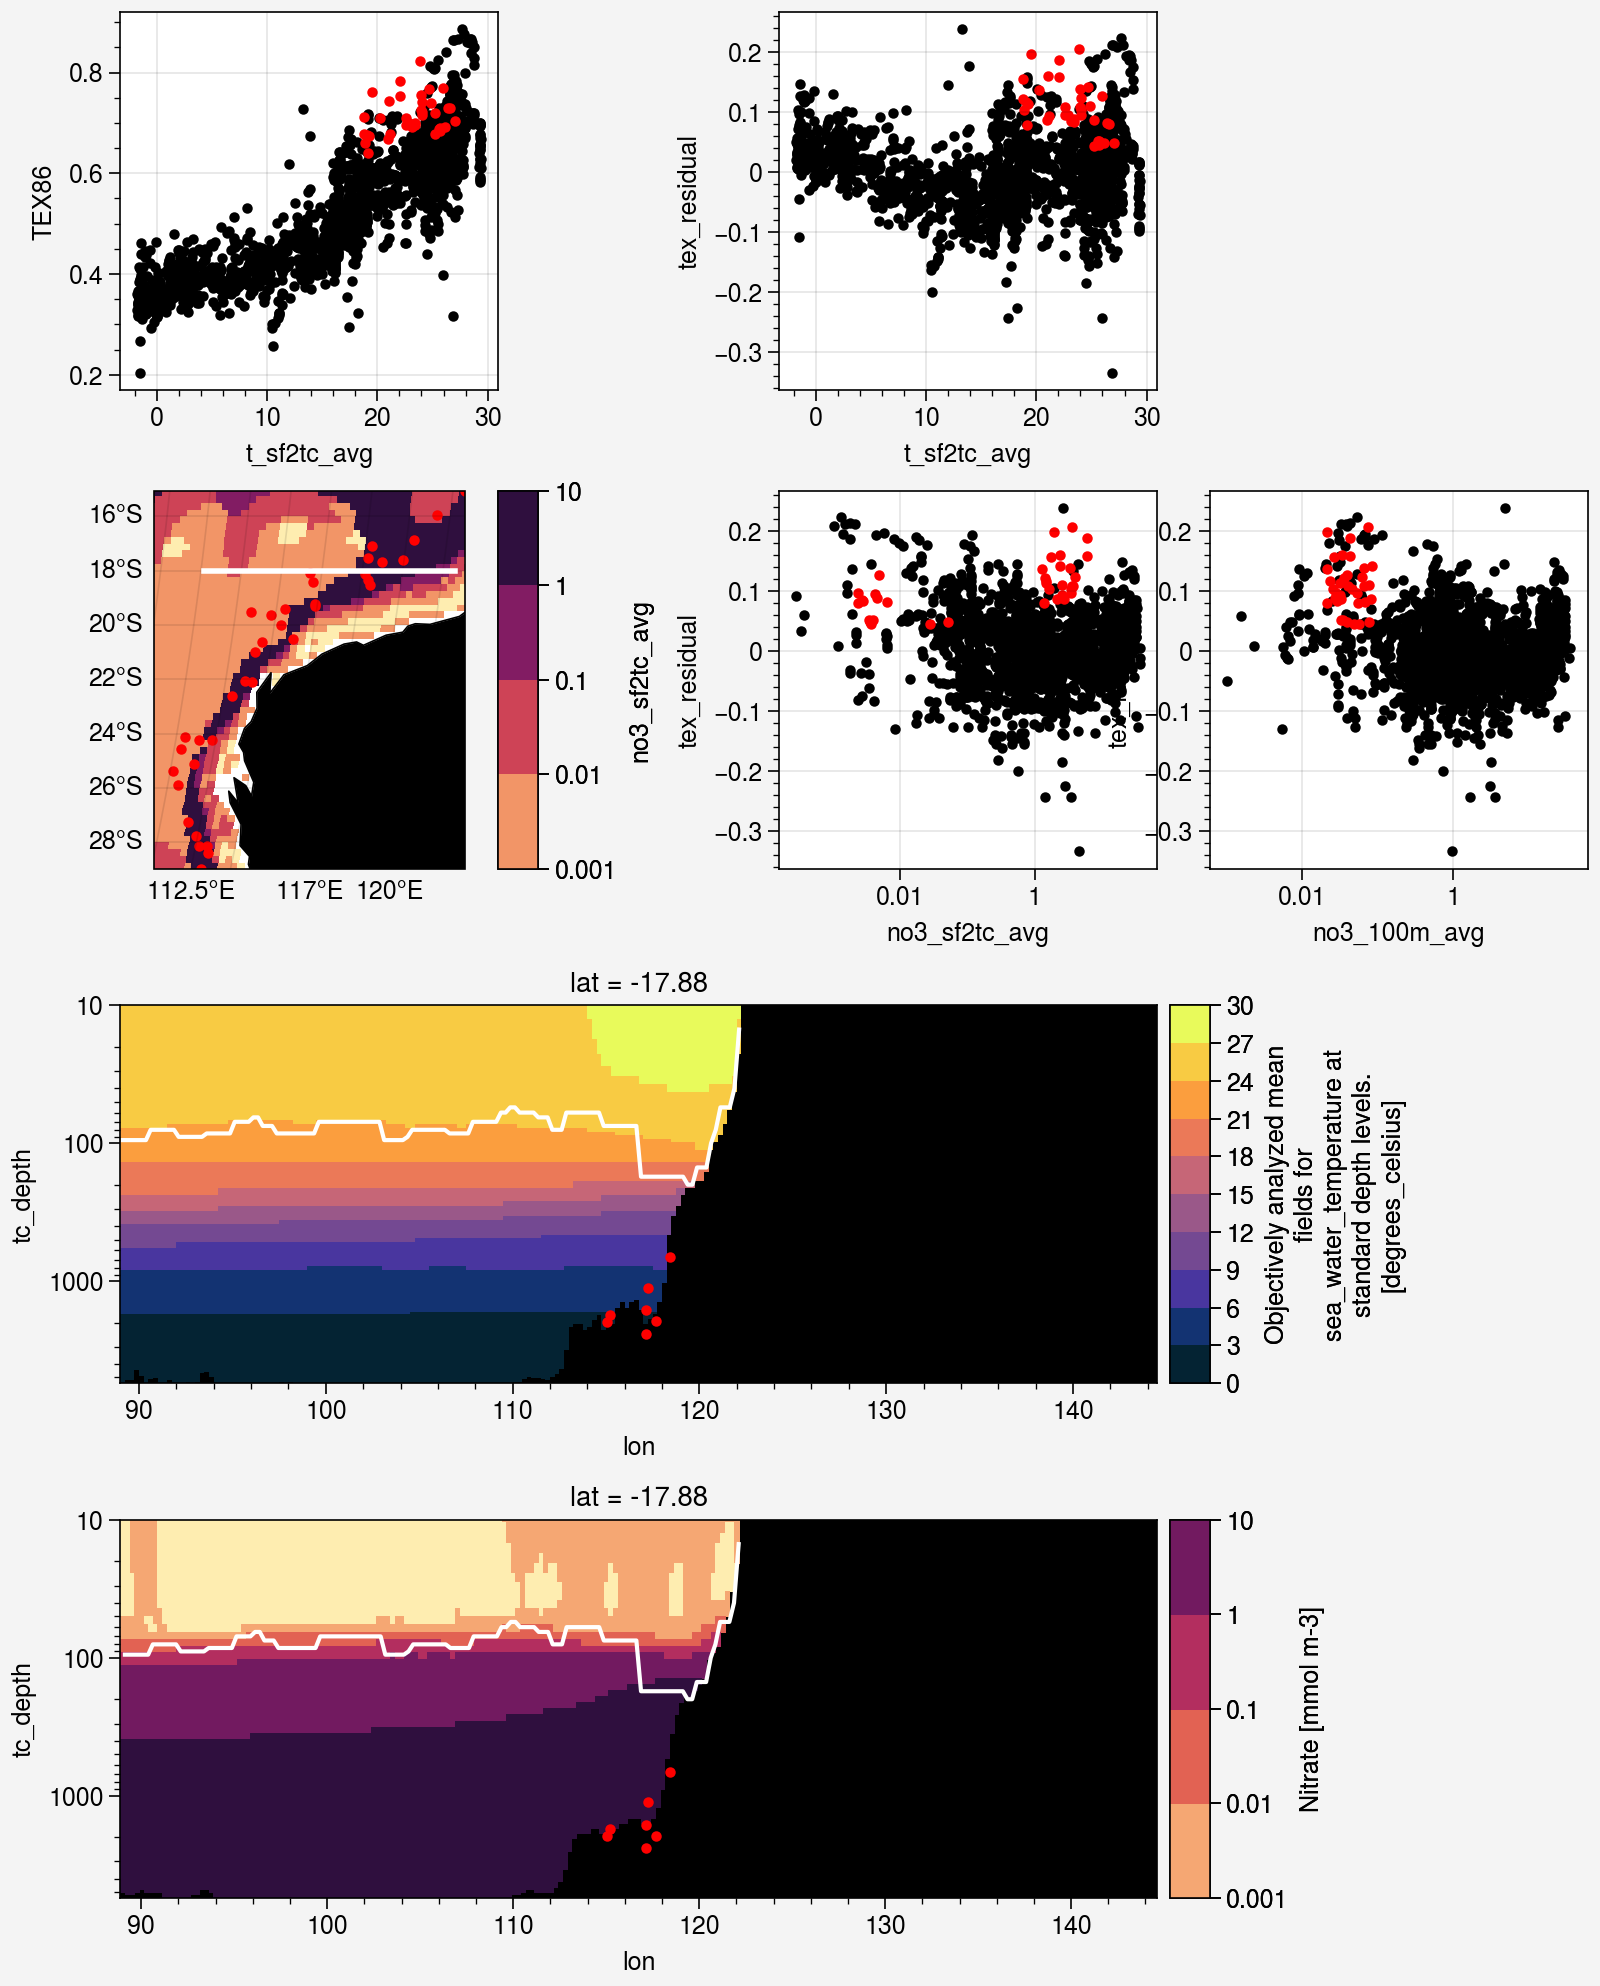

In [12]:
array = [
    [1,2,0],
    [3,4,7],
    [5,5,0],
    [6,6,0],
]

fig, axs = plot.subplots(array,width=8,
                         proj=(None,None,'eck3',None,None),share=0)

plot_data = coretop_df
ax = axs[0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['TEX86']
ax.scatter(plot_x, plot_y, color='k', s=10, label='Coretops')

plot_data = trang_coretop_df
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['TEX86']
ax.scatter(plot_x, plot_y, color='r', s=10, label='Transect coretops')

ax = axs[1]
plot_data = coretop_df
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='k', s=10, label='Coretops')

plot_data = trang_coretop_df
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='r', s=10, label='Transect coretops')

ax = axs[2]
maxLat = trang_coretop_df['Latitude'].max()
minLat = trang_coretop_df['Latitude'].min()
maxLon = trang_coretop_df['Longitude'].max()
minLon = trang_coretop_df['Longitude'].min()
ax.format(
    lonlim=(minLon, maxLon), latlim=(minLat, maxLat),
    land=True, labels=True, coast=True
)

ds['no3_sf2tc_avg'].sel(lat=slice(minLat,maxLat),
                        lon=slice(minLon*0.8,maxLon*1.2)).plot(ax=ax, 
                                                               robust=True,
                                                       levels=[1e-3,1e-2,1e-1,1e0,1e1,],
                                                       cmap='matter', add_colorbar=True)
### add latitude trasect line
sel_lat = -18
ax.plot([minLon,maxLon],[sel_lat,sel_lat],color='w',lw=2)                       
                        
plot_data = trang_coretop_df
plot_lat = plot_data['Latitude']
plot_lon = plot_data['Longitude']
ax.scatter(plot_lon, plot_lat, color='r', s=10, label='Trang coretops')

ax = axs[3]
plot_data = coretop_df
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='k', s=10, label='Coretops')

plot_data = trang_coretop_df
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='r', s=10, label='Transect coretops')

ax.format(
    xscale='log'
)

ax = axs[6]
plot_data = coretop_df
plot_x = plot_data['no3_100m_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='k', s=10, label='Coretops')

plot_data = trang_coretop_df
plot_x = plot_data['no3_100m_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='r', s=10, label='Transect coretops')

ax.format(
    xscale='log'
)


ax = axs[4]

T_da.sel(lon=slice(minLon*0.8,maxLon*1.2)).sel(lat=sel_lat, method='nearest').plot(ax=ax,
                                                                                   robust=True,
                                                                                   levels=10,
                                                                                   cmap='thermal')
plot_data = trang_coretop_df[trang_coretop_df['Latitude'].between(sel_lat-0.5,sel_lat+0.5)]
plot_lon = plot_data['Longitude']
plot_depth = plot_data['WaterDepth']
ax.scatter(plot_lon, plot_depth*np.ones_like(plot_lon), color='r', s=10, label='Trang coretops')
ax.format(
    ylim=(5500,10),
    yscale='log',
    facecolor='k'
)

ds['tc_depth'].sel(lon=slice(minLon*0.8,maxLon*1.2)).sel(lat=sel_lat, method='nearest').plot(ax=ax,c='w')

ax = axs[5]
nitrate_CMEMS_da.sel(lon=slice(minLon*0.8,maxLon*1.2)).sel(lat=sel_lat, method='nearest').plot(ax=ax,robust=True,
                                                                                   levels=[1e-3,1e-2,1e-1,1e0,1e1,],
                                                                                   cmap='matter')
ds['tc_depth'].sel(lon=slice(minLon*0.8,maxLon*1.2)).sel(lat=sel_lat, method='nearest').plot(ax=ax,c='w')
plot_data = trang_coretop_df[trang_coretop_df['Latitude'].between(sel_lat-0.5,sel_lat+0.5)]
plot_lon = plot_data['Longitude']
plot_depth = plot_data['WaterDepth']
ax.scatter(plot_lon, plot_depth*np.ones_like(plot_lon), color='r', s=10, label='Trang coretops')
ax.format(
    ylim=(5500,10),
    yscale='log',
    facecolor='k'
)

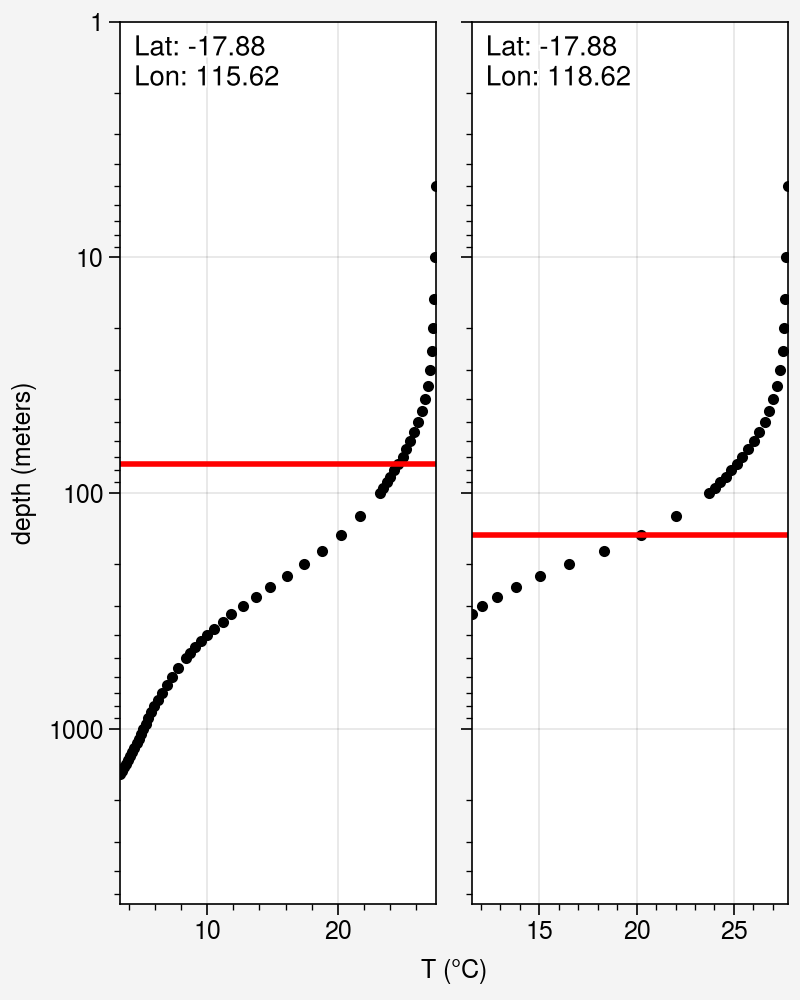

In [13]:
fig, axs = plot.subplots(figsize=(4,5),ncols=2)

ax = axs[0]
sel_lat = -18
sel_lon =115.5
temp_data = T_da.sel(lat=sel_lat, lon=sel_lon, method='nearest')
match_lat = T_da.sel(lat=sel_lat, method='nearest').lat
match_lon = T_da.sel(lon=sel_lon, method='nearest').lon
depths = T_da.depth
plot_x = temp_data
plot_y = depths
ax.plot(plot_x, plot_y,'.', color='k', lw=2)

## calculate thermocline depth based on the maximum gradient
grad = np.gradient(temp_data)/np.gradient(depths)
grad_min = np.nanmin(grad)
grad_min_idx = np.where(grad == grad_min)[0][0]
thermocline_depth = depths[grad_min_idx]
ax.axhline(thermocline_depth, color='r', lw=2)


ax.format(
    ultitle='Lat: {:.2f}\nLon: {:.2f}'.format(match_lat.values, match_lon.values),
    xreverse=False,
    ylim=(1500,1),
    yscale='log',
    xlabel='T ($\degree$C)',
)

ax = axs[1]
sel_lat = -18
sel_lon =118.5
temp_data = T_da.sel(lat=sel_lat, lon=sel_lon, method='nearest')
match_lat = T_da.sel(lat=sel_lat, method='nearest').lat
match_lon = T_da.sel(lon=sel_lon, method='nearest').lon
depths = T_da.depth
plot_x = temp_data
plot_y = depths
ax.plot(plot_x, plot_y,'.', color='k', lw=2)

## calculate thermocline depth based on the maximum gradient
grad = np.gradient(temp_data)/np.gradient(depths)
grad_min = np.nanmin(grad)
grad_min_idx = np.where(grad == grad_min)[0][0]
thermocline_depth = depths[grad_min_idx]
ax.axhline(thermocline_depth, color='r', lw=2)


ax.format(
    ultitle='Lat: {:.2f}\nLon: {:.2f}'.format(match_lat.values, match_lon.values),
    xreverse=False,
    ylim=(5500,1),
    yscale='log',
    xlabel='T ($\degree$C)',
)